# Load saved churn inference pipeline
This notebook loads the serialized inference pipeline and runs a quick smoke test.

In [1]:
%pip install shap -q
import joblib
import pandas as pd
import numpy as np
import shap
print('shap', shap.__version__)
# Helper used by the serialized pipeline (define before loading)
def map_yes_no(values):
    array = np.asarray(values)
    return (array == 'Yes').astype(int)
model_path = 'churn_inference_pipeline.joblib'
pipeline = joblib.load(model_path)
print('Loaded pipeline type:', type(pipeline))
try:
    display(pipeline)
except Exception:
    print(pipeline)


[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: D:\MLOPs project\.venv\Scripts\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


shap 0.49.1
Loaded pipeline type: <class 'sklearn.pipeline.Pipeline'>


,steps,"[('preprocessor', ...), ('estimator', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [2]:
# Quick smoke test: predict probabilities on first 10 rows of the raw CSV
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
X_sample = df.drop(columns=['customerID','Churn'], errors='ignore').head(10)
if hasattr(pipeline, 'predict_proba'):
    probs = pipeline.predict_proba(X_sample)[:,1]
else:
    probs = pipeline.predict(X_sample)
out = pd.DataFrame({'index': X_sample.index, 'churn_proba': probs})
display(out)

,index,churn_proba
0,0,0.715882
1,1,0.148181
2,2,0.605437
3,3,0.136329
4,4,0.837710
5,5,0.861346
6,6,0.680303
7,7,0.470394
8,8,0.684069
9,9,0.155813


Next steps: compute SHAP values for the tuned RF, create customer segments by churn probability, and recommend retention actions.

## Phase 2: Model Evaluation Visualizations

Generate three evaluation visualizations for the tuned Random Forest model on the test set.

In [3]:
# Prepare test data for evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

# Load and prepare data
df_eval = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_eval['TotalCharges'] = pd.to_numeric(df_eval['TotalCharges'], errors='coerce').fillna(0)
X_eval = df_eval.drop(columns=['customerID', 'Churn'], errors='ignore')
y_eval = df_eval['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

# Split with same random state as original training
X_train_eval, X_test_eval, y_train_eval, y_test_eval = train_test_split(
    X_eval, y_eval, test_size=0.2, random_state=42, stratify=y_eval
)

# Get predictions from the pipeline
y_pred = pipeline.predict(X_test_eval)
y_proba = pipeline.predict_proba(X_test_eval)[:, 1]

print(f'Test set shape: {X_test_eval.shape}')
print(f'Actual Churn distribution:\n{y_test_eval.value_counts()}')

Test set shape: (1409, 19)
Actual Churn distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


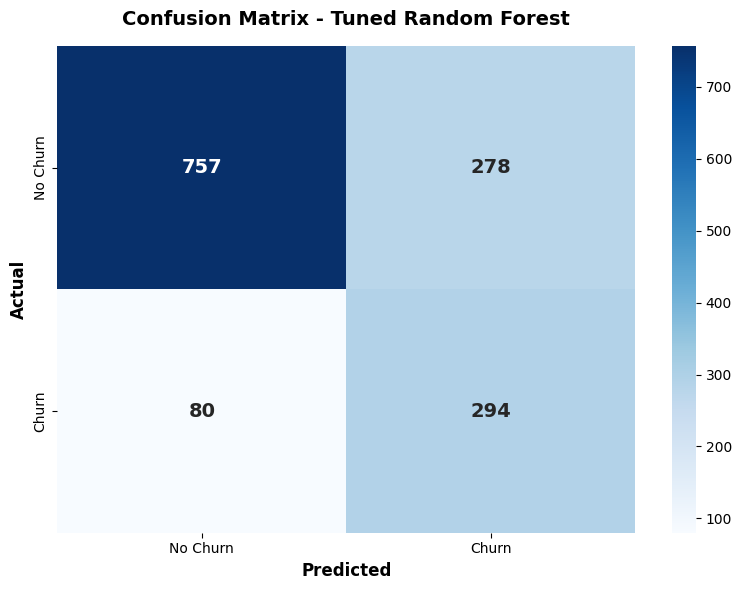

Accuracy: 0.7459
Precision: 0.5140
Recall: 0.7861
F1 Score: 0.6216


In [4]:
# 1) Confusion Matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test_eval, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix - Tuned Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print metrics
accuracy = accuracy_score(y_test_eval, y_pred)
precision = precision_score(y_test_eval, y_pred)
recall = recall_score(y_test_eval, y_pred)
f1 = f1_score(y_test_eval, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

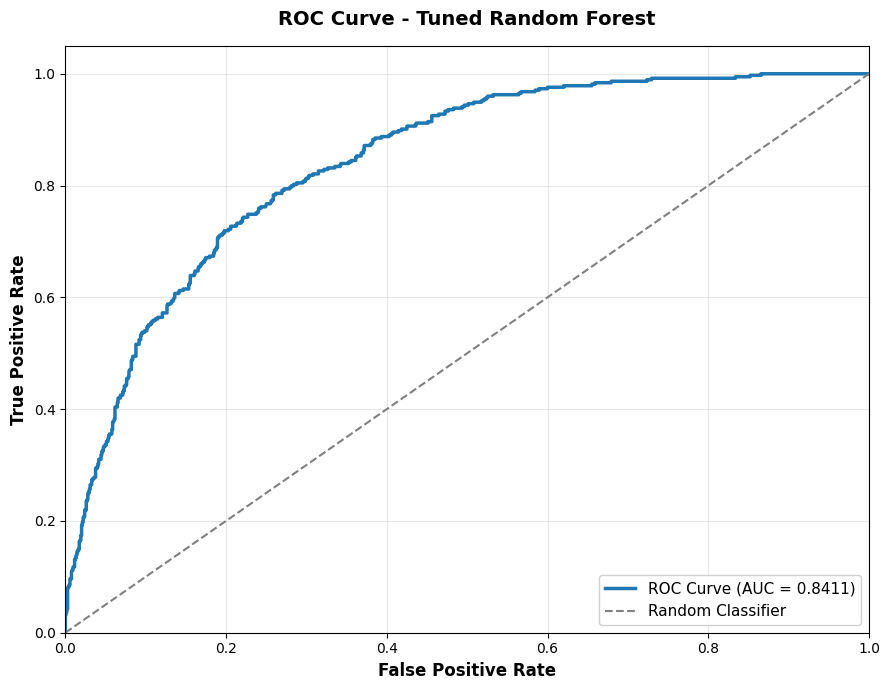

ROC AUC Score: 0.8411


In [5]:
# 2) ROC Curve with AUC
from sklearn.metrics import roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test_eval, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(9, 7))
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Tuned Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'ROC AUC Score: {roc_auc:.4f}')

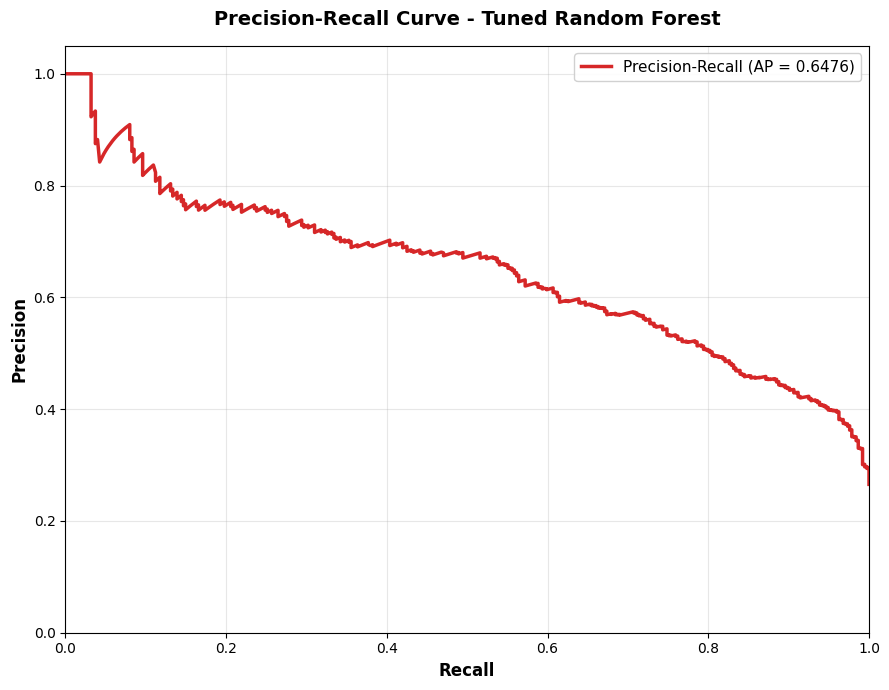

Average Precision Score: 0.6476


In [6]:
# 3) Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test_eval, y_proba)
avg_precision = average_precision_score(y_test_eval, y_proba)

plt.figure(figsize=(9, 7))
plt.plot(recall_vals, precision_vals, color='#d62728', lw=2.5, label=f'Precision-Recall (AP = {avg_precision:.4f})')
plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curve - Tuned Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='best', fontsize=11, framealpha=0.9)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Average Precision Score: {avg_precision:.4f}')

## SHAP Analysis - Feature Importance & Explainability

Global SHAP Summary Plot showing the impact of each feature on model predictions.

In [7]:
# Compute SHAP values and visualize
import matplotlib.pyplot as plt

# Prepare the feature matrix and processed features
X = df.drop(columns=['customerID','Churn'], errors='ignore').copy()
preprocessor = pipeline.named_steps.get('preprocessor', None)
model = pipeline.named_steps.get('estimator', pipeline)

if preprocessor is None:
    X_proc = X.copy()
    feature_names = list(X_proc.columns)
else:
    X_proc = preprocessor.transform(X)
    try:
        feature_names = preprocessor.get_feature_names_out()
    except Exception:
        feature_names = [f'f{i}' for i in range(X_proc.shape[1])]

# Convert to DataFrame for SHAP display utilities
X_proc_df = pd.DataFrame(X_proc, columns=feature_names, index=X.index)

# Create SHAP explainer and compute values
shap_vals = None
try:
    explainer = shap.Explainer(model, X_proc_df)
    shap_exp = explainer(X_proc_df)
    if shap_exp.values.ndim == 3:
        shap_vals = shap_exp.values[:, 1, :]
    else:
        shap_vals = shap_exp.values
except Exception:
    try:
        tree_expl = shap.TreeExplainer(model)
        shap_vals_raw = tree_expl.shap_values(X_proc_df)
        if isinstance(shap_vals_raw, list):
            shap_vals = shap_vals_raw[1] if len(shap_vals_raw) > 1 else shap_vals_raw[0]
        else:
            shap_vals = shap_vals_raw
    except Exception as e:
        print('Failed to compute SHAP values:', e)
        shap_vals = None

# Align SHAP array to feature matrix columns if needed
if shap_vals is not None:
    try:
        n_feat = X_proc_df.shape[1]
        if shap_vals.ndim == 3:
            shap_vals = shap_vals.reshape(shap_vals.shape[0], -1)
        if shap_vals.shape[1] > n_feat:
            shap_vals = shap_vals[:, :n_feat]
        elif shap_vals.shape[1] < n_feat:
            print('SHAP values have fewer features than data; using available values')
            shap_vals = None
    except Exception:
        pass

# Plot global summary
if shap_vals is not None:
    plt.figure(figsize=(10, 8))
    try:
        shap.summary_plot(shap_vals, X_proc_df, show=True)
    except Exception:
        try:
            shap.summary_plot(shap_vals, X_proc_df, plot_type='bar', show=True)
        except Exception as e:
            print('Could not create SHAP summary plot:', e)
else:
    print('No SHAP values available to plot.')

print('SHAP analysis complete.')

  3%|=                   | 464/14086 [00:11<05:22]       

  4%|=                   | 507/14086 [00:12<05:21]       

  4%|=                   | 549/14086 [00:13<05:20]       

  4%|=                   | 590/14086 [00:14<05:20]       

  4%|=                   | 632/14086 [00:15<05:19]       

  5%|=                   | 675/14086 [00:16<05:17]       

  5%|=                   | 718/14086 [00:17<05:16]       

  5%|=                   | 761/14086 [00:18<05:15]       

  6%|=                   | 802/14086 [00:19<05:14]       

  6%|=                   | 844/14086 [00:20<05:13]       

  6%|=                   | 881/14086 [00:21<05:14]       

  7%|=                   | 922/14086 [00:22<05:14]       

  7%|=                   | 966/14086 [00:23<05:12]       

  7%|=                   | 1006/14086 [00:24<05:12]       

  7%|=                   | 1049/14086 [00:25<05:10]       

  8%|==                  | 1091/14086 [00:26<05:09]       

  8%|==                  | 1135/14086 [00:27<05:08]       

  8%|==                  | 1177/14086 [00:28<05:07]       

  9%|==                  | 1219/14086 [00:29<05:06]       

  9%|==                  | 1261/14086 [00:30<05:05]       

  9%|==                  | 1301/14086 [00:31<05:04]       

 10%|==                  | 1343/14086 [00:32<05:03]       

 10%|==                  | 1385/14086 [00:33<05:02]       

 10%|==                  | 1427/14086 [00:34<05:01]       

 10%|==                  | 1471/14086 [00:35<05:00]       

 11%|==                  | 1513/14086 [00:36<04:59]       

 11%|==                  | 1557/14086 [00:37<04:57]       

 11%|==                  | 1598/14086 [00:38<04:56]       

 12%|==                  | 1641/14086 [00:39<04:55]       

 12%|==                  | 1683/14086 [00:40<04:54]       

 12%|==                  | 1721/14086 [00:41<04:54]       

 13%|===                 | 1763/14086 [00:42<04:53]       

 13%|===                 | 1805/14086 [00:43<04:52]       

 13%|===                 | 1847/14086 [00:44<04:51]       

 13%|===                 | 1891/14086 [00:45<04:50]       

 14%|===                 | 1934/14086 [00:46<04:49]       

 14%|===                 | 1976/14086 [00:47<04:48]       

 14%|===                 | 2019/14086 [00:48<04:46]       

 15%|===                 | 2056/14086 [00:49<04:46]       

 15%|===                 | 2096/14086 [00:50<04:46]       

 15%|===                 | 2137/14086 [00:51<04:45]       

 15%|===                 | 2178/14086 [00:52<04:44]       

 16%|===                 | 2220/14086 [00:53<04:43]       

 16%|===                 | 2261/14086 [00:54<04:42]       

 16%|===                 | 2304/14086 [00:55<04:41]       

 17%|===                 | 2347/14086 [00:56<04:40]       

 17%|===                 | 2386/14086 [00:57<04:39]       

 17%|===                 | 2425/14086 [00:58<04:38]       

 17%|===                 | 2463/14086 [00:59<04:38]       

 18%|====                | 2502/14086 [01:00<04:37]       

 18%|====                | 2542/14086 [01:01<04:37]       

 18%|====                | 2578/14086 [01:02<04:36]       

 19%|====                | 2620/14086 [01:03<04:35]       

 19%|====                | 2661/14086 [01:04<04:34]       

 19%|====                | 2705/14086 [01:05<04:33]       

 20%|====                | 2747/14086 [01:06<04:32]       

 20%|====                | 2790/14086 [01:07<04:31]       

 20%|====                | 2832/14086 [01:08<04:30]       

 20%|====                | 2875/14086 [01:09<04:29]       

 21%|====                | 2917/14086 [01:10<04:28]       

 21%|====                | 2958/14086 [01:11<04:27]       

 21%|====                | 3001/14086 [01:12<04:25]       

 22%|====                | 3044/14086 [01:13<04:24]       

 22%|====                | 3085/14086 [01:14<04:23]       

 22%|====                | 3129/14086 [01:15<04:22]       

 23%|=====               | 3173/14086 [01:16<04:21]       

 23%|=====               | 3215/14086 [01:17<04:20]       

 23%|=====               | 3258/14086 [01:18<04:19]       

 23%|=====               | 3301/14086 [01:19<04:18]       

 24%|=====               | 3341/14086 [01:20<04:17]       

 24%|=====               | 3382/14086 [01:21<04:16]       

 24%|=====               | 3425/14086 [01:22<04:15]       

 25%|=====               | 3468/14086 [01:23<04:14]       

 25%|=====               | 3508/14086 [01:24<04:13]       

 25%|=====               | 3550/14086 [01:25<04:12]       

 26%|=====               | 3592/14086 [01:26<04:11]       

 26%|=====               | 3635/14086 [01:27<04:10]       

 26%|=====               | 3676/14086 [01:28<04:09]       

 26%|=====               | 3718/14086 [01:29<04:08]       

 27%|=====               | 3761/14086 [01:30<04:07]       

 27%|=====               | 3801/14086 [01:31<04:06]       

 27%|=====               | 3843/14086 [01:32<04:05]       

 28%|======              | 3886/14086 [01:33<04:04]       

 28%|======              | 3926/14086 [01:34<04:03]       

 28%|======              | 3970/14086 [01:35<04:02]       

 28%|======              | 4012/14086 [01:36<04:01]       

 29%|======              | 4054/14086 [01:37<04:00]       

 29%|======              | 4097/14086 [01:38<03:58]       

 29%|======              | 4137/14086 [01:39<03:58]       

 30%|======              | 4178/14086 [01:40<03:57]       

 30%|======              | 4215/14086 [01:41<03:56]       

 30%|======              | 4257/14086 [01:42<03:55]       

 31%|======              | 4298/14086 [01:43<03:54]       

 31%|======              | 4340/14086 [01:44<03:53]       

 31%|======              | 4383/14086 [01:45<03:52]       

 31%|======              | 4428/14086 [01:46<03:51]       

 32%|======              | 4470/14086 [01:47<03:50]       

 32%|======              | 4513/14086 [01:48<03:49]       

 32%|======              | 4555/14086 [01:49<03:48]       

 33%|=======             | 4596/14086 [01:50<03:47]       

 33%|=======             | 4638/14086 [01:51<03:46]       

 33%|=======             | 4680/14086 [01:52<03:45]       

 34%|=======             | 4722/14086 [01:53<03:44]       

 34%|=======             | 4762/14086 [01:54<03:43]       

 34%|=======             | 4800/14086 [01:55<03:42]       

 34%|=======             | 4837/14086 [01:56<03:41]       

 35%|=======             | 4876/14086 [01:57<03:40]       

 35%|=======             | 4915/14086 [01:58<03:40]       

 35%|=======             | 4957/14086 [01:59<03:39]       

 35%|=======             | 5000/14086 [02:00<03:38]       

 36%|=======             | 5041/14086 [02:01<03:37]       

 36%|=======             | 5083/14086 [02:02<03:36]       

 36%|=======             | 5127/14086 [02:03<03:34]       

 37%|=======             | 5169/14086 [02:04<03:33]       

 37%|=======             | 5212/14086 [02:05<03:32]       

 37%|=======             | 5254/14086 [02:06<03:31]       

 38%|========            | 5297/14086 [02:07<03:30]       

 38%|========            | 5341/14086 [02:08<03:29]       

 38%|========            | 5383/14086 [02:09<03:28]       

 39%|========            | 5425/14086 [02:10<03:27]       

 39%|========            | 5467/14086 [02:11<03:26]       

 39%|========            | 5510/14086 [02:12<03:25]       

 39%|========            | 5552/14086 [02:13<03:24]       

 40%|========            | 5594/14086 [02:14<03:23]       

 40%|========            | 5638/14086 [02:15<03:22]       

 40%|========            | 5680/14086 [02:16<03:21]       

 41%|========            | 5723/14086 [02:17<03:20]       

 41%|========            | 5765/14086 [02:18<03:19]       

 41%|========            | 5808/14086 [02:19<03:18]       

 42%|========            | 5849/14086 [02:20<03:17]       

 42%|========            | 5889/14086 [02:21<03:16]       

 42%|========            | 5932/14086 [02:22<03:15]       

 42%|========            | 5976/14086 [02:23<03:14]       

 43%|=========           | 6017/14086 [02:24<03:13]       

 43%|=========           | 6060/14086 [02:25<03:12]       

 43%|=========           | 6103/14086 [02:26<03:10]       

 44%|=========           | 6147/14086 [02:27<03:09]       

 44%|=========           | 6190/14086 [02:28<03:08]       

 44%|=========           | 6232/14086 [02:29<03:07]       

 45%|=========           | 6271/14086 [02:30<03:06]       

 45%|=========           | 6310/14086 [02:31<03:06]       

 45%|=========           | 6353/14086 [02:32<03:05]       

 45%|=========           | 6391/14086 [02:33<03:04]       

 46%|=========           | 6432/14086 [02:34<03:03]       

 46%|=========           | 6475/14086 [02:35<03:02]       

 46%|=========           | 6517/14086 [02:36<03:01]       

 47%|=========           | 6559/14086 [02:37<03:00]       

 47%|=========           | 6596/14086 [02:38<02:59]       

 47%|=========           | 6639/14086 [02:39<02:58]       

 47%|=========           | 6682/14086 [02:40<02:57]       

 48%|==========          | 6719/14086 [02:41<02:56]       

 48%|==========          | 6761/14086 [02:42<02:55]       

 48%|==========          | 6801/14086 [02:43<02:54]       

 49%|==========          | 6842/14086 [02:44<02:53]       

 49%|==========          | 6886/14086 [02:45<02:52]       

 49%|==========          | 6930/14086 [02:46<02:51]       

 50%|==========          | 6973/14086 [02:47<02:50]       

 50%|==========          | 7017/14086 [02:48<02:49]       

 50%|==========          | 7060/14086 [02:49<02:48]       

 50%|==========          | 7101/14086 [02:50<02:47]       

 51%|==========          | 7143/14086 [02:51<02:46]       

 51%|==========          | 7185/14086 [02:52<02:45]       

 51%|==========          | 7227/14086 [02:53<02:44]       

 52%|==========          | 7268/14086 [02:54<02:43]       

 52%|==========          | 7311/14086 [02:55<02:42]       

 52%|==========          | 7354/14086 [02:56<02:41]       

 53%|===========         | 7397/14086 [02:57<02:40]       

 53%|===========         | 7443/14086 [02:58<02:38]       

 53%|===========         | 7486/14086 [02:59<02:37]       

 53%|===========         | 7528/14086 [03:00<02:36]       

 54%|===========         | 7570/14086 [03:01<02:35]       

 54%|===========         | 7612/14086 [03:02<02:34]       

 54%|===========         | 7654/14086 [03:03<02:33]       

 55%|===========         | 7698/14086 [03:04<02:32]       

 55%|===========         | 7741/14086 [03:05<02:31]       

 55%|===========         | 7784/14086 [03:06<02:30]       

 56%|===========         | 7827/14086 [03:07<02:29]       

 56%|===========         | 7872/14086 [03:08<02:28]       

 56%|===========         | 7914/14086 [03:09<02:27]       

 56%|===========         | 7956/14086 [03:10<02:26]       

 57%|===========         | 7996/14086 [03:11<02:25]       

 57%|===========         | 8039/14086 [03:12<02:24]       

 57%|===========         | 8080/14086 [03:13<02:23]       

 58%|============        | 8119/14086 [03:14<02:22]       

 58%|============        | 8162/14086 [03:15<02:21]       

 58%|============        | 8206/14086 [03:16<02:20]       

 59%|============        | 8250/14086 [03:17<02:19]       

 59%|============        | 8292/14086 [03:18<02:18]       

 59%|============        | 8335/14086 [03:19<02:17]       

 59%|============        | 8377/14086 [03:20<02:16]       

 60%|============        | 8419/14086 [03:21<02:15]       

 60%|============        | 8457/14086 [03:22<02:14]       

 60%|============        | 8500/14086 [03:23<02:13]       

 61%|============        | 8542/14086 [03:24<02:12]       

 61%|============        | 8585/14086 [03:25<02:11]       

 61%|============        | 8628/14086 [03:26<02:10]       

 62%|============        | 8669/14086 [03:27<02:09]       

 62%|============        | 8712/14086 [03:28<02:08]       

 62%|============        | 8755/14086 [03:29<02:07]       

 62%|============        | 8797/14086 [03:30<02:06]       

 63%|=============       | 8838/14086 [03:31<02:05]       

 63%|=============       | 8880/14086 [03:32<02:04]       

 63%|=============       | 8922/14086 [03:33<02:03]       

 64%|=============       | 8964/14086 [03:34<02:02]       

 64%|=============       | 9002/14086 [03:35<02:01]       

 64%|=============       | 9045/14086 [03:36<02:00]       

 65%|=============       | 9087/14086 [03:37<01:59]       

 65%|=============       | 9130/14086 [03:38<01:58]       

 65%|=============       | 9173/14086 [03:39<01:57]       

 65%|=============       | 9214/14086 [03:40<01:56]       

 66%|=============       | 9251/14086 [03:41<01:55]       

 66%|=============       | 9294/14086 [03:42<01:54]       

 66%|=============       | 9335/14086 [03:43<01:53]       

 67%|=============       | 9377/14086 [03:44<01:52]       

 67%|=============       | 9415/14086 [03:45<01:51]       

 67%|=============       | 9458/14086 [03:46<01:50]       

 67%|=============       | 9498/14086 [03:47<01:49]       

 68%|==============      | 9540/14086 [03:48<01:48]       

 68%|==============      | 9582/14086 [03:49<01:47]       

 68%|==============      | 9622/14086 [03:50<01:46]       

 69%|==============      | 9660/14086 [03:51<01:45]       

 69%|==============      | 9697/14086 [03:52<01:45]       

 69%|==============      | 9735/14086 [03:53<01:44]       

 69%|==============      | 9778/14086 [03:54<01:43]       

 70%|==============      | 9820/14086 [03:55<01:42]       

 70%|==============      | 9864/14086 [03:56<01:41]       

 70%|==============      | 9906/14086 [03:57<01:40]       

 71%|==============      | 9950/14086 [03:58<01:38]       

 71%|==============      | 9992/14086 [03:59<01:37]       

 71%|==============      | 10035/14086 [04:00<01:36]       

 72%|==============      | 10077/14086 [04:01<01:35]       

 72%|==============      | 10118/14086 [04:02<01:34]       

 72%|==============      | 10161/14086 [04:03<01:33]       

 72%|==============      | 10204/14086 [04:04<01:32]       

 73%|===============     | 10247/14086 [04:05<01:31]       

 73%|===============     | 10285/14086 [04:06<01:30]       

 73%|===============     | 10322/14086 [04:07<01:30]       

 74%|===============     | 10362/14086 [04:08<01:29]       

 74%|===============     | 10401/14086 [04:09<01:28]       

 74%|===============     | 10444/14086 [04:10<01:27]       

 74%|===============     | 10485/14086 [04:11<01:26]       

 75%|===============     | 10526/14086 [04:12<01:25]       

 75%|===============     | 10568/14086 [04:13<01:24]       

 75%|===============     | 10607/14086 [04:14<01:23]       

 76%|===============     | 10651/14086 [04:15<01:22]       

 76%|===============     | 10694/14086 [04:16<01:21]       

 76%|===============     | 10738/14086 [04:17<01:20]       

 77%|===============     | 10781/14086 [04:18<01:19]       

 77%|===============     | 10824/14086 [04:19<01:18]       

 77%|===============     | 10866/14086 [04:20<01:17]       

 77%|===============     | 10908/14086 [04:21<01:16]       

 78%|================    | 10948/14086 [04:22<01:15]       

 78%|================    | 10989/14086 [04:23<01:14]       

 78%|================    | 11031/14086 [04:24<01:13]       

 79%|================    | 11073/14086 [04:25<01:12]       

 79%|================    | 11117/14086 [04:26<01:11]       

 79%|================    | 11157/14086 [04:27<01:10]       

 79%|================    | 11195/14086 [04:28<01:09]       

 80%|================    | 11227/14086 [04:29<01:08]       

 80%|================    | 11269/14086 [04:30<01:07]       

 80%|================    | 11313/14086 [04:31<01:06]       

 81%|================    | 11355/14086 [04:32<01:05]       

 81%|================    | 11398/14086 [04:33<01:04]       

 81%|================    | 11439/14086 [04:34<01:03]       

 82%|================    | 11484/14086 [04:35<01:02]       

 82%|================    | 11525/14086 [04:36<01:01]       

 82%|================    | 11564/14086 [04:37<01:00]       

 82%|================    | 11608/14086 [04:38<00:59]       

 83%|=================   | 11651/14086 [04:39<00:58]       

 83%|=================   | 11692/14086 [04:40<00:57]       

 83%|=================   | 11732/14086 [04:41<00:56]       

 84%|=================   | 11774/14086 [04:42<00:55]       

 84%|=================   | 11816/14086 [04:43<00:54]       

 84%|=================   | 11857/14086 [04:44<00:53]       

 84%|=================   | 11899/14086 [04:45<00:52]       

 85%|=================   | 11943/14086 [04:46<00:51]       

 85%|=================   | 11983/14086 [04:47<00:50]       

 85%|=================   | 12025/14086 [04:48<00:49]       

 86%|=================   | 12064/14086 [04:49<00:48]       

 86%|=================   | 12104/14086 [04:50<00:47]       

 86%|=================   | 12147/14086 [04:51<00:46]       

 87%|=================   | 12188/14086 [04:52<00:45]       

 87%|=================   | 12230/14086 [04:53<00:44]       

 87%|=================   | 12271/14086 [04:54<00:43]       

 87%|=================   | 12313/14086 [04:55<00:42]       

 88%|==================  | 12351/14086 [04:56<00:41]       

 88%|==================  | 12393/14086 [04:57<00:40]       

 88%|==================  | 12436/14086 [04:58<00:39]       

 89%|==================  | 12477/14086 [04:59<00:38]       

 89%|==================  | 12520/14086 [05:00<00:37]       

 89%|==================  | 12564/14086 [05:01<00:36]       

 89%|==================  | 12603/14086 [05:02<00:35]       

 90%|==================  | 12646/14086 [05:03<00:34]       

 90%|==================  | 12688/14086 [05:04<00:33]       

 90%|==================  | 12730/14086 [05:05<00:32]       

 91%|==================  | 12773/14086 [05:06<00:31]       

 91%|==================  | 12815/14086 [05:07<00:30]       

 91%|==================  | 12859/14086 [05:08<00:29]       

 92%|==================  | 12901/14086 [05:09<00:28]       

 92%|==================  | 12944/14086 [05:10<00:27]       

 92%|==================  | 12985/14086 [05:11<00:26]       

 93%|=================== | 13030/14086 [05:12<00:25]       

 93%|=================== | 13071/14086 [05:13<00:24]       

 93%|=================== | 13113/14086 [05:14<00:23]       

 93%|=================== | 13156/14086 [05:15<00:22]       

 94%|=================== | 13198/14086 [05:16<00:21]       

 94%|=================== | 13241/14086 [05:17<00:20]       

 94%|=================== | 13281/14086 [05:18<00:19]       

 95%|=================== | 13323/14086 [05:19<00:18]       

 95%|=================== | 13365/14086 [05:20<00:17]       

 95%|=================== | 13407/14086 [05:21<00:16]       

 95%|=================== | 13449/14086 [05:22<00:15]       

 96%|=================== | 13491/14086 [05:23<00:14]       

 96%|=================== | 13532/14086 [05:24<00:13]       

 96%|=================== | 13567/14086 [05:25<00:12]       

 97%|=================== | 13606/14086 [05:26<00:11]       

 97%|=================== | 13643/14086 [05:27<00:10]       

 97%|=================== | 13681/14086 [05:28<00:09]       

 97%|=================== | 13721/14086 [05:29<00:08]       

 98%|===================| 13759/14086 [05:30<00:07]       

 98%|===================| 13800/14086 [05:31<00:06]       

 98%|===================| 13843/14086 [05:32<00:05]       

 99%|===================| 13883/14086 [05:33<00:04]       

 99%|===================| 13922/14086 [05:34<00:03]       

 99%|===================| 13962/14086 [05:35<00:02]       

 99%|===================| 14001/14086 [05:36<00:02]       

100%|===================| 14043/14086 [05:37<00:01]       

100%|===================| 14081/14086 [05:38<00:00]       

SHAP values have fewer features than data; using available values
No SHAP values available to plot.
SHAP analysis complete.


## Customer Segmentation & Business Intelligence

Analyze customer segments by churn probability and provide actionable retention strategies.

In [8]:
# Compute churn probabilities and create business segments
X_full = df.drop(columns=['customerID','Churn'], errors='ignore').copy()
probas = pipeline.predict_proba(X_full)[:, 1] if hasattr(pipeline, 'predict_proba') else pipeline.predict(X_full)
df_seg = df.copy()
df_seg['churn_proba'] = probas

# Business thresholds and definitions
high_value_thresh = df_seg['TotalCharges'].quantile(0.75)

# Define segments
conditions = [
    (df_seg['churn_proba'] >= 0.6) & (df_seg['TotalCharges'] >= high_value_thresh),
    (df_seg['churn_proba'] >= 0.6) & (df_seg['tenure'] <= 6),
    (df_seg['churn_proba'] >= 0.4) & (df_seg['churn_proba'] < 0.6),
]
choices = ['High-Value Flight Risk', 'New-Customer Flight Risk', 'Mid-Risk Retention Opportunity']
df_seg['segment'] = np.select(conditions, choices, default='Low Risk')

# Aggregate summary metrics for each segment
summary = df_seg.groupby('segment').agg(
    count=('churn_proba', 'size'),
    pct_of_customers=('churn_proba', lambda x: 100 * x.size / df_seg.shape[0]),
    avg_churn_proba=('churn_proba', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
).reset_index()

# Add business-friendly descriptions and recommended actions
descriptions = {
    'High-Value Flight Risk': 'High predicted churn and high lifetime value (top 25% TotalCharges).',
    'New-Customer Flight Risk': 'Recently acquired customers with high predicted churn (tenure <= 6 months).',
    'Mid-Risk Retention Opportunity': 'Moderate predicted churn — good candidates for targeted offers.',
    'Low Risk': 'Low predicted churn; standard engagement.'
}
actions = {
    'High-Value Flight Risk': 'Immediate retention: VIP outreach, custom discounts, account review, loyalty incentives.',
    'New-Customer Flight Risk': 'Onboarding improvements: targeted welcome offers, quick-check calls, trial extensions.',
    'Mid-Risk Retention Opportunity': 'Nudge campaigns: time-limited promotions, bundle suggestions, service checks.',
    'Low Risk': 'Standard lifecycle marketing.'
}
summary['characteristics'] = summary['segment'].map(descriptions)
summary['recommended_action'] = summary['segment'].map(actions)

# Reorder columns for presentation
summary = summary[[
    'segment', 'count', 'pct_of_customers', 'avg_churn_proba',
    'avg_monthly_charges', 'avg_tenure', 'characteristics', 'recommended_action'
]]

print('='*100)
print('CUSTOMER SEGMENTATION SUMMARY')
print('='*100)
display(summary)

# Save to CSV
summary.to_csv('churn_segments_summary.csv', index=False)
print('\nSaved churn_segments_summary.csv')

CUSTOMER SEGMENTATION SUMMARY


,segment,count,pct_of_customers,avg_churn_proba,avg_monthly_charges,avg_tenure,characteristics,recommended_action
0,High-Value Flight Risk,190,2.697714,0.667610,96.442105,51.478947,High predicted churn and high lifetime value (...,"Immediate retention: VIP outreach, custom disc..."
1,Low Risk,4626,65.682238,0.298561,62.801773,39.368569,Low predicted churn; standard engagement.,Standard lifecycle marketing.
2,Mid-Risk Retention Opportunity,1234,17.520943,0.502321,65.567261,27.286062,Moderate predicted churn — good candidates for...,"Nudge campaigns: time-limited promotions, bund..."
3,New-Customer Flight Risk,993,14.099105,0.777316,66.829406,2.436052,Recently acquired customers with high predicte...,Onboarding improvements: targeted welcome offe...



Saved churn_segments_summary.csv


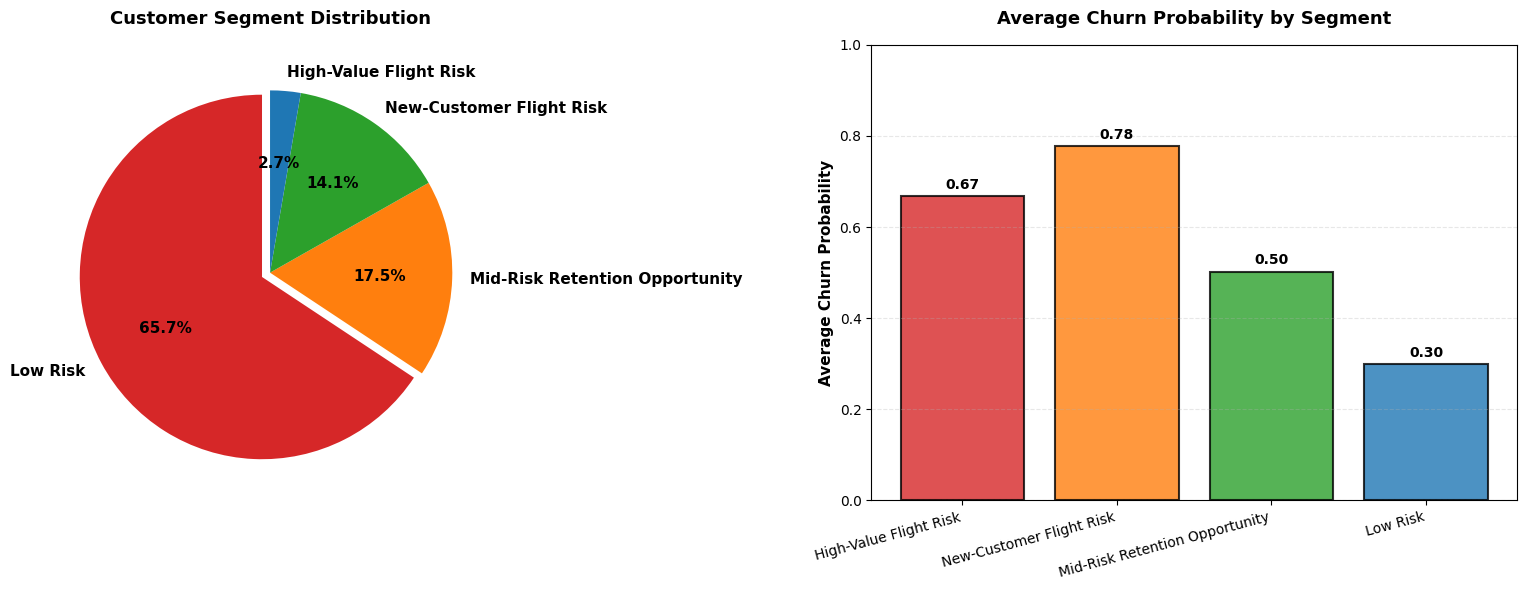

Total customers: 7043


In [9]:
# Segmentation Visualizations

# 1) Segment Distribution (Pie Chart)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

segment_counts = df_seg['segment'].value_counts()
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
explode = [0.05 if x == segment_counts.max() else 0 for x in segment_counts.values]

ax1.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
        colors=colors, explode=explode, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
ax1.set_title('Customer Segment Distribution', fontsize=13, fontweight='bold', pad=15)

# 2) Segment Bar Chart with Churn Probability
segment_order = ['High-Value Flight Risk', 'New-Customer Flight Risk', 'Mid-Risk Retention Opportunity', 'Low Risk']
segment_data = summary.set_index('segment').loc[segment_order]

bars = ax2.bar(range(len(segment_data)), segment_data['avg_churn_proba'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(segment_data)))
ax2.set_xticklabels(segment_data.index, rotation=15, ha='right', fontsize=10)
ax2.set_ylabel('Average Churn Probability', fontsize=11, fontweight='bold')
ax2.set_title('Average Churn Probability by Segment', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylim([0, 1.0])
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    ax2.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Total customers: {len(df_seg)}')

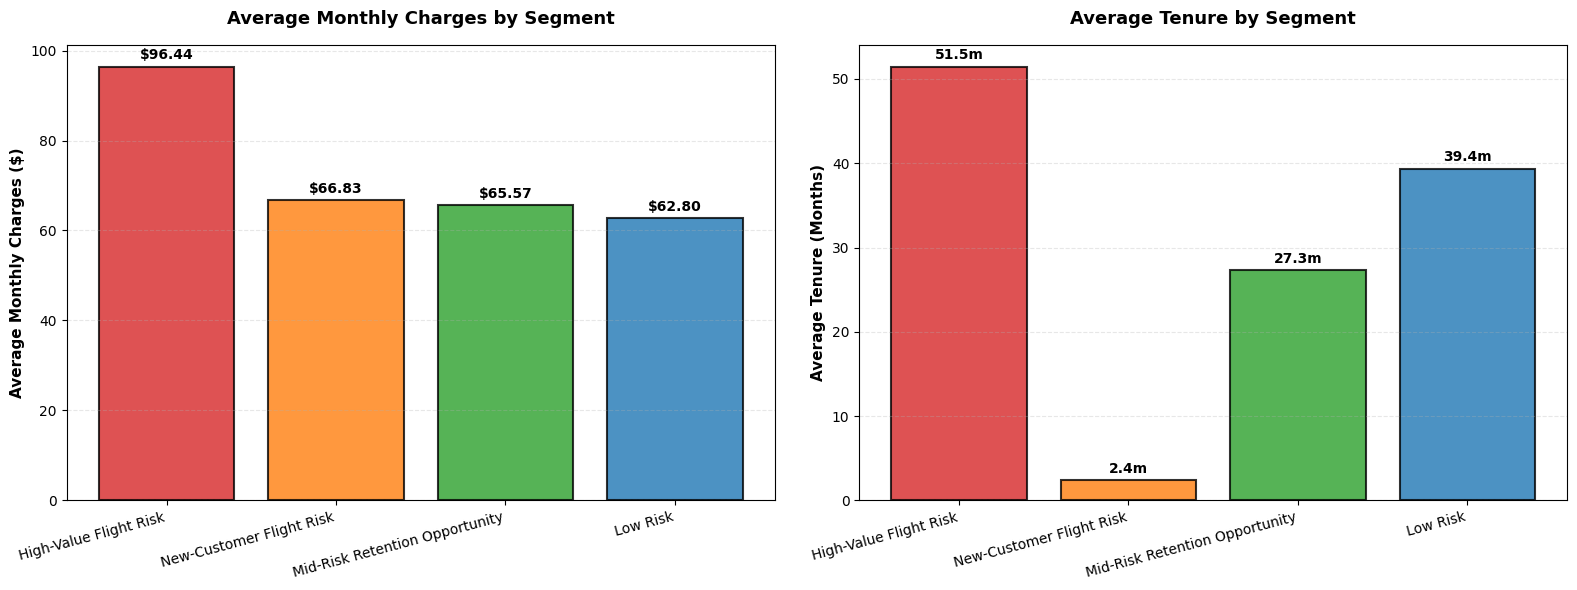

Segmentation analysis complete. All visualizations have been generated.


In [10]:
# Segment Characteristics: Monthly Charges and Tenure by Segment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

segment_order = ['High-Value Flight Risk', 'New-Customer Flight Risk', 'Mid-Risk Retention Opportunity', 'Low Risk']
segment_data = summary.set_index('segment').loc[segment_order]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

# Monthly Charges by Segment
bars1 = ax1.bar(range(len(segment_data)), segment_data['avg_monthly_charges'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xticks(range(len(segment_data)))
ax1.set_xticklabels(segment_data.index, rotation=15, ha='right', fontsize=10)
ax1.set_ylabel('Average Monthly Charges ($)', fontsize=11, fontweight='bold')
ax1.set_title('Average Monthly Charges by Segment', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'${height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')

# Tenure by Segment
bars2 = ax2.bar(range(len(segment_data)), segment_data['avg_tenure'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(segment_data)))
ax2.set_xticklabels(segment_data.index, rotation=15, ha='right', fontsize=10)
ax2.set_ylabel('Average Tenure (Months)', fontsize=11, fontweight='bold')
ax2.set_title('Average Tenure by Segment', fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}m',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('Segmentation analysis complete. All visualizations have been generated.')

In [11]:
# Compute SHAP values and show a global summary plot
import matplotlib.pyplot as plt
# Prepare the feature matrix and processed features
X = df.drop(columns=['customerID','Churn'], errors='ignore').copy()
preprocessor = pipeline.named_steps.get('preprocessor', None)
model = pipeline.named_steps.get('estimator', pipeline)
if preprocessor is None:
    X_proc = X.copy()
    feature_names = list(X_proc.columns)
else:
    X_proc = preprocessor.transform(X)
    try:
        feature_names = preprocessor.get_feature_names_out()
    except Exception:
        feature_names = [f'f{i}' for i in range(X_proc.shape[1])]

# Convert to DataFrame for SHAP display utilities
X_proc_df = pd.DataFrame(X_proc, columns=feature_names, index=X.index)

# Create SHAP explainer and compute values (handle classifier outputs)
shap_vals = None
try:
    explainer = shap.Explainer(model, X_proc_df)
    shap_exp = explainer(X_proc_df)
    if shap_exp.values.ndim == 3:
        shap_vals = shap_exp.values[:, 1, :]
    else:
        shap_vals = shap_exp.values
except Exception:
    try:
        tree_expl = shap.TreeExplainer(model)
        shap_vals_raw = tree_expl.shap_values(X_proc_df)
        if isinstance(shap_vals_raw, list):
            shap_vals = shap_vals_raw[1] if len(shap_vals_raw) > 1 else shap_vals_raw[0]
        else:
            shap_vals = shap_vals_raw
    except Exception as e:
        print('Failed to compute SHAP values:', e)
        shap_vals = None

# Align SHAP array to feature matrix columns if needed
if shap_vals is not None:
    try:
        n_feat = X_proc_df.shape[1]
        if shap_vals.ndim == 3:
            shap_vals = shap_vals.reshape(shap_vals.shape[0], -1)
        if shap_vals.shape[1] > n_feat:
            shap_vals = shap_vals[:, :n_feat]
        elif shap_vals.shape[1] < n_feat:
            print('SHAP values have fewer features than data; skipping plot')
            shap_vals = None
    except Exception:
        pass

# Plot global summary if we have SHAP values
if shap_vals is not None:
    plt.figure(figsize=(8, 6))
    try:
        shap.summary_plot(shap_vals, X_proc_df, show=True)
    except Exception:
        shap.summary_plot(shap_vals, X_proc_df, plot_type='bar', show=True)
else:
    print('No SHAP values available to plot.')

  3%|=                   | 441/14086 [00:11<05:40]       

  3%|=                   | 483/14086 [00:12<05:37]       

  4%|=                   | 525/14086 [00:13<05:35]       

  4%|=                   | 566/14086 [00:14<05:34]       

  4%|=                   | 609/14086 [00:15<05:31]       

  5%|=                   | 650/14086 [00:16<05:30]       

  5%|=                   | 693/14086 [00:17<05:28]       

  5%|=                   | 733/14086 [00:18<05:27]       

  5%|=                   | 774/14086 [00:19<05:26]       

  6%|=                   | 817/14086 [00:20<05:24]       

  6%|=                   | 858/14086 [00:21<05:23]       

  6%|=                   | 896/14086 [00:22<05:23]       

  7%|=                   | 937/14086 [00:23<05:22]       

  7%|=                   | 980/14086 [00:24<05:20]       

  7%|=                   | 1022/14086 [00:25<05:19]       

  8%|==                  | 1064/14086 [00:26<05:18]       

  8%|==                  | 1107/14086 [00:27<05:16]       

  8%|==                  | 1149/14086 [00:28<05:15]       

  8%|==                  | 1191/14086 [00:29<05:13]       

  9%|==                  | 1234/14086 [00:30<05:12]       

  9%|==                  | 1276/14086 [00:31<05:11]       

  9%|==                  | 1315/14086 [00:32<05:10]       

 10%|==                  | 1353/14086 [00:33<05:10]       

 10%|==                  | 1393/14086 [00:34<05:09]       

 10%|==                  | 1434/14086 [00:35<05:08]       

 10%|==                  | 1475/14086 [00:36<05:07]       

 11%|==                  | 1516/14086 [00:37<05:06]       

 11%|==                  | 1557/14086 [00:38<05:05]       

 11%|==                  | 1599/14086 [00:39<05:04]       

 12%|==                  | 1641/14086 [00:40<05:03]       

 12%|==                  | 1683/14086 [00:41<05:02]       

 12%|==                  | 1725/14086 [00:42<05:00]       

 13%|===                 | 1763/14086 [00:43<05:00]       

 13%|===                 | 1799/14086 [00:44<05:00]       

 13%|===                 | 1837/14086 [00:45<05:00]       

 13%|===                 | 1877/14086 [00:46<04:59]       

 14%|===                 | 1921/14086 [00:47<04:57]       

 14%|===                 | 1961/14086 [00:48<04:56]       

 14%|===                 | 2001/14086 [00:49<04:55]       

 14%|===                 | 2038/14086 [00:50<04:55]       

 15%|===                 | 2079/14086 [00:51<04:54]       

 15%|===                 | 2113/14086 [00:52<04:54]       

 15%|===                 | 2155/14086 [00:53<04:53]       

 16%|===                 | 2196/14086 [00:54<04:52]       

 16%|===                 | 2237/14086 [00:55<04:51]       

 16%|===                 | 2278/14086 [00:56<04:50]       

 16%|===                 | 2315/14086 [00:57<04:49]       

 17%|===                 | 2357/14086 [00:58<04:48]       

 17%|===                 | 2399/14086 [00:59<04:47]       

 17%|===                 | 2437/14086 [01:00<04:46]       

 18%|====                | 2479/14086 [01:01<04:45]       

 18%|====                | 2522/14086 [01:02<04:44]       

 18%|====                | 2565/14086 [01:03<04:42]       

 19%|====                | 2606/14086 [01:04<04:41]       

 19%|====                | 2649/14086 [01:05<04:40]       

 19%|====                | 2692/14086 [01:06<04:39]       

 19%|====                | 2733/14086 [01:07<04:38]       

 20%|====                | 2775/14086 [01:08<04:37]       

 20%|====                | 2810/14086 [01:09<04:36]       

 20%|====                | 2851/14086 [01:10<04:35]       

 21%|====                | 2890/14086 [01:11<04:35]       

 21%|====                | 2941/14086 [01:12<04:32]       

 21%|====                | 3015/14086 [01:13<04:28]       

 22%|====                | 3068/14086 [01:14<04:25]       

 22%|====                | 3105/14086 [01:15<04:25]       

 22%|====                | 3141/14086 [01:16<04:24]       

 23%|=====               | 3181/14086 [01:17<04:23]       

 23%|=====               | 3222/14086 [01:18<04:23]       

 23%|=====               | 3258/14086 [01:19<04:22]       

 23%|=====               | 3293/14086 [01:20<04:22]       

 24%|=====               | 3324/14086 [01:21<04:22]       

 24%|=====               | 3356/14086 [01:22<04:22]       

 24%|=====               | 3393/14086 [01:23<04:21]       

 24%|=====               | 3432/14086 [01:24<04:20]       

 25%|=====               | 3468/14086 [01:25<04:20]       

 25%|=====               | 3502/14086 [01:26<04:19]       

 25%|=====               | 3537/14086 [01:27<04:19]       

 25%|=====               | 3572/14086 [01:28<04:19]       

 26%|=====               | 3606/14086 [01:29<04:18]       

 26%|=====               | 3634/14086 [01:30<04:18]       

 26%|=====               | 3664/14086 [01:31<04:18]       

 26%|=====               | 3695/14086 [01:32<04:18]       

 26%|=====               | 3727/14086 [01:33<04:18]       

 27%|=====               | 3766/14086 [01:34<04:17]       

 27%|=====               | 3806/14086 [01:35<04:16]       

 27%|=====               | 3838/14086 [01:36<04:16]       

 27%|=====               | 3868/14086 [01:37<04:16]       

 28%|======              | 3901/14086 [01:38<04:15]       

 28%|======              | 3940/14086 [01:39<04:14]       

 28%|======              | 3975/14086 [01:40<04:14]       

 28%|======              | 4010/14086 [01:41<04:13]       

 29%|======              | 4048/14086 [01:42<04:12]       

 29%|======              | 4087/14086 [01:43<04:11]       

 29%|======              | 4126/14086 [01:44<04:11]       

 30%|======              | 4166/14086 [01:45<04:10]       

 30%|======              | 4199/14086 [01:46<04:09]       

 30%|======              | 4235/14086 [01:47<04:08]       

 30%|======              | 4271/14086 [01:48<04:08]       

 31%|======              | 4308/14086 [01:49<04:07]       

 31%|======              | 4345/14086 [01:50<04:06]       

 31%|======              | 4383/14086 [01:51<04:05]       

 31%|======              | 4423/14086 [01:52<04:04]       

 32%|======              | 4461/14086 [01:53<04:03]       

 32%|======              | 4498/14086 [01:54<04:03]       

 32%|======              | 4536/14086 [01:55<04:02]       

 32%|======              | 4573/14086 [01:56<04:01]       

 33%|=======             | 4612/14086 [01:57<04:00]       

 33%|=======             | 4651/14086 [01:58<03:59]       

 33%|=======             | 4689/14086 [01:59<03:58]       

 34%|=======             | 4725/14086 [02:00<03:57]       

 34%|=======             | 4751/14086 [02:01<03:57]       

 34%|=======             | 4783/14086 [02:02<03:57]       

 34%|=======             | 4812/14086 [02:03<03:57]       

 34%|=======             | 4846/14086 [02:04<03:56]       

 35%|=======             | 4880/14086 [02:05<03:55]       

 35%|=======             | 4913/14086 [02:06<03:55]       

 35%|=======             | 4947/14086 [02:07<03:54]       

 35%|=======             | 4977/14086 [02:08<03:54]       

 36%|=======             | 5010/14086 [02:09<03:53]       

 36%|=======             | 5044/14086 [02:10<03:53]       

 36%|=======             | 5076/14086 [02:11<03:52]       

 36%|=======             | 5107/14086 [02:12<03:52]       

 36%|=======             | 5139/14086 [02:13<03:51]       

 37%|=======             | 5170/14086 [02:14<03:51]       

 37%|=======             | 5202/14086 [02:15<03:50]       

 37%|=======             | 5232/14086 [02:16<03:50]       

 37%|=======             | 5266/14086 [02:17<03:49]       

 38%|========            | 5299/14086 [02:18<03:48]       

 38%|========            | 5330/14086 [02:19<03:48]       

 38%|========            | 5362/14086 [02:20<03:47]       

 38%|========            | 5394/14086 [02:21<03:47]       

 39%|========            | 5426/14086 [02:22<03:46]       

 39%|========            | 5464/14086 [02:23<03:45]       

 39%|========            | 5502/14086 [02:24<03:44]       

 39%|========            | 5542/14086 [02:25<03:43]       

 40%|========            | 5578/14086 [02:26<03:42]       

 40%|========            | 5619/14086 [02:27<03:41]       

 40%|========            | 5657/14086 [02:28<03:40]       

 40%|========            | 5693/14086 [02:29<03:39]       

 41%|========            | 5728/14086 [02:30<03:38]       

 41%|========            | 5769/14086 [02:31<03:37]       

 41%|========            | 5810/14086 [02:32<03:36]       

 42%|========            | 5851/14086 [02:33<03:35]       

 42%|========            | 5887/14086 [02:34<03:34]       

 42%|========            | 5917/14086 [02:35<03:33]       

 42%|========            | 5951/14086 [02:36<03:33]       

 42%|========            | 5983/14086 [02:37<03:32]       

 43%|=========           | 6015/14086 [02:38<03:32]       

 43%|=========           | 6039/14086 [02:39<03:31]       

 43%|=========           | 6067/14086 [02:40<03:31]       

 43%|=========           | 6100/14086 [02:41<03:30]       

 44%|=========           | 6134/14086 [02:42<03:30]       

 44%|=========           | 6172/14086 [02:43<03:29]       

 44%|=========           | 6208/14086 [02:44<03:28]       

 44%|=========           | 6249/14086 [02:45<03:26]       

 45%|=========           | 6285/14086 [02:46<03:26]       

 45%|=========           | 6330/14086 [02:47<03:24]       

 45%|=========           | 6387/14086 [02:48<03:22]       

 46%|=========           | 6452/14086 [02:49<03:19]       

 46%|=========           | 6511/14086 [02:50<03:17]       

 47%|=========           | 6566/14086 [02:51<03:15]       

 47%|=========           | 6621/14086 [02:52<03:13]       

 47%|=========           | 6672/14086 [02:53<03:12]       

 48%|==========          | 6736/14086 [02:54<03:09]       

 48%|==========          | 6796/14086 [02:55<03:07]       

 49%|==========          | 6861/14086 [02:56<03:05]       

 49%|==========          | 6922/14086 [02:57<03:03]       

 50%|==========          | 6979/14086 [02:58<03:01]       

 50%|==========          | 7039/14086 [02:59<02:59]       

 50%|==========          | 7103/14086 [03:00<02:56]       

 51%|==========          | 7157/14086 [03:01<02:55]       

 51%|==========          | 7216/14086 [03:02<02:53]       

 52%|==========          | 7273/14086 [03:03<02:51]       

 52%|==========          | 7342/14086 [03:04<02:49]       

 53%|===========         | 7411/14086 [03:05<02:46]       

 53%|===========         | 7478/14086 [03:06<02:44]       

 54%|===========         | 7539/14086 [03:07<02:42]       

 54%|===========         | 7597/14086 [03:08<02:40]       

 54%|===========         | 7670/14086 [03:09<02:38]       

 55%|===========         | 7749/14086 [03:10<02:35]       

 55%|===========         | 7807/14086 [03:11<02:33]       

 56%|===========         | 7843/14086 [03:12<02:32]       

 56%|===========         | 7881/14086 [03:13<02:31]       

 56%|===========         | 7918/14086 [03:14<02:31]       

 56%|===========         | 7954/14086 [03:15<02:30]       

 57%|===========         | 7992/14086 [03:16<02:29]       

 57%|===========         | 8035/14086 [03:17<02:28]       

 57%|===========         | 8078/14086 [03:18<02:27]       

 58%|============        | 8122/14086 [03:19<02:26]       

 58%|============        | 8163/14086 [03:20<02:25]       

 58%|============        | 8206/14086 [03:21<02:24]       

 59%|============        | 8247/14086 [03:22<02:23]       

 59%|============        | 8287/14086 [03:23<02:22]       

 59%|============        | 8324/14086 [03:24<02:21]       

 59%|============        | 8361/14086 [03:25<02:20]       

 60%|============        | 8401/14086 [03:26<02:19]       

 60%|============        | 8439/14086 [03:27<02:18]       

 60%|============        | 8477/14086 [03:28<02:17]       

 60%|============        | 8516/14086 [03:29<02:16]       

 61%|============        | 8555/14086 [03:30<02:15]       

 61%|============        | 8598/14086 [03:31<02:14]       

 61%|============        | 8639/14086 [03:32<02:13]       

 62%|============        | 8676/14086 [03:33<02:12]       

 62%|============        | 8719/14086 [03:34<02:11]       

 62%|============        | 8761/14086 [03:35<02:10]       

 62%|============        | 8799/14086 [03:36<02:09]       

 63%|=============       | 8838/14086 [03:37<02:08]       

 63%|=============       | 8877/14086 [03:38<02:07]       

 63%|=============       | 8915/14086 [03:39<02:07]       

 64%|=============       | 8958/14086 [03:40<02:05]       

 64%|=============       | 8995/14086 [03:41<02:05]       

 64%|=============       | 9033/14086 [03:42<02:04]       

 64%|=============       | 9070/14086 [03:43<02:03]       

 65%|=============       | 9111/14086 [03:44<02:02]       

 65%|=============       | 9154/14086 [03:45<02:01]       

 65%|=============       | 9195/14086 [03:46<02:00]       

 66%|=============       | 9236/14086 [03:47<01:59]       

 66%|=============       | 9278/14086 [03:48<01:58]       

 66%|=============       | 9320/14086 [03:49<01:57]       

 66%|=============       | 9360/14086 [03:50<01:56]       

 67%|=============       | 9398/14086 [03:51<01:55]       

 67%|=============       | 9442/14086 [03:52<01:54]       

 67%|=============       | 9484/14086 [03:53<01:53]       

 68%|==============      | 9523/14086 [03:54<01:52]       

 68%|==============      | 9561/14086 [03:55<01:51]       

 68%|==============      | 9599/14086 [03:56<01:50]       

 68%|==============      | 9639/14086 [03:57<01:49]       

 69%|==============      | 9683/14086 [03:58<01:48]       

 69%|==============      | 9725/14086 [03:59<01:47]       

 69%|==============      | 9763/14086 [04:00<01:46]       

 70%|==============      | 9805/14086 [04:01<01:45]       

 70%|==============      | 9844/14086 [04:02<01:44]       

 70%|==============      | 9881/14086 [04:03<01:43]       

 70%|==============      | 9918/14086 [04:04<01:42]       

 71%|==============      | 9961/14086 [04:05<01:41]       

 71%|==============      | 10004/14086 [04:06<01:40]       

 71%|==============      | 10046/14086 [04:07<01:39]       

 72%|==============      | 10089/14086 [04:08<01:38]       

 72%|==============      | 10131/14086 [04:09<01:37]       

 72%|==============      | 10171/14086 [04:10<01:36]       

 73%|===============     | 10214/14086 [04:11<01:35]       

 73%|===============     | 10252/14086 [04:12<01:34]       

 73%|===============     | 10293/14086 [04:13<01:33]       

 73%|===============     | 10335/14086 [04:14<01:32]       

 74%|===============     | 10377/14086 [04:15<01:31]       

 74%|===============     | 10420/14086 [04:16<01:30]       

 74%|===============     | 10462/14086 [04:17<01:29]       

 75%|===============     | 10504/14086 [04:18<01:27]       

 75%|===============     | 10542/14086 [04:19<01:27]       

 75%|===============     | 10582/14086 [04:20<01:26]       

 75%|===============     | 10624/14086 [04:21<01:25]       

 76%|===============     | 10669/14086 [04:22<01:23]       

 76%|===============     | 10710/14086 [04:23<01:22]       

 76%|===============     | 10754/14086 [04:24<01:21]       

 77%|===============     | 10796/14086 [04:25<01:20]       

 77%|===============     | 10835/14086 [04:26<01:19]       

 77%|===============     | 10871/14086 [04:27<01:18]       

 77%|===============     | 10908/14086 [04:28<01:18]       

 78%|================    | 10950/14086 [04:29<01:17]       

 78%|================    | 10992/14086 [04:30<01:15]       

 78%|================    | 11034/14086 [04:31<01:14]       

 79%|================    | 11076/14086 [04:32<01:13]       

 79%|================    | 11114/14086 [04:33<01:13]       

 79%|================    | 11154/14086 [04:34<01:12]       

 79%|================    | 11196/14086 [04:35<01:10]       

 80%|================    | 11237/14086 [04:36<01:09]       

 80%|================    | 11273/14086 [04:37<01:09]       

 80%|================    | 11315/14086 [04:38<01:08]       

 81%|================    | 11356/14086 [04:39<01:07]       

 81%|================    | 11399/14086 [04:40<01:06]       

 81%|================    | 11441/14086 [04:41<01:04]       

 82%|================    | 11486/14086 [04:42<01:03]       

 82%|================    | 11527/14086 [04:43<01:02]       

 82%|================    | 11567/14086 [04:44<01:01]       

 82%|================    | 11607/14086 [04:45<01:00]       

 83%|=================   | 11644/14086 [04:46<00:59]       

 83%|=================   | 11686/14086 [04:47<00:58]       

 83%|=================   | 11723/14086 [04:48<00:58]       

 84%|=================   | 11764/14086 [04:49<00:57]       

 84%|=================   | 11807/14086 [04:50<00:55]       

 84%|=================   | 11848/14086 [04:51<00:54]       

 84%|=================   | 11892/14086 [04:52<00:53]       

 85%|=================   | 11932/14086 [04:53<00:52]       

 85%|=================   | 11974/14086 [04:54<00:51]       

 85%|=================   | 12016/14086 [04:55<00:50]       

 86%|=================   | 12056/14086 [04:56<00:49]       

 86%|=================   | 12097/14086 [04:57<00:48]       

 86%|=================   | 12140/14086 [04:58<00:47]       

 87%|=================   | 12186/14086 [04:59<00:46]       

 87%|=================   | 12223/14086 [05:00<00:45]       

 87%|=================   | 12265/14086 [05:01<00:44]       

 87%|=================   | 12307/14086 [05:02<00:43]       

 88%|==================  | 12349/14086 [05:03<00:42]       

 88%|==================  | 12391/14086 [05:04<00:41]       

 88%|==================  | 12433/14086 [05:05<00:40]       

 89%|==================  | 12475/14086 [05:06<00:39]       

 89%|==================  | 12518/14086 [05:07<00:38]       

 89%|==================  | 12555/14086 [05:08<00:37]       

 89%|==================  | 12595/14086 [05:09<00:36]       

 90%|==================  | 12631/14086 [05:10<00:35]       

 90%|==================  | 12669/14086 [05:11<00:34]       

 90%|==================  | 12708/14086 [05:12<00:33]       

 91%|==================  | 12748/14086 [05:13<00:32]       

 91%|==================  | 12789/14086 [05:14<00:31]       

 91%|==================  | 12832/14086 [05:15<00:30]       

 91%|==================  | 12873/14086 [05:16<00:29]       

 92%|==================  | 12916/14086 [05:17<00:28]       

 92%|==================  | 12958/14086 [05:18<00:27]       

 92%|==================  | 13000/14086 [05:19<00:26]       

 93%|=================== | 13042/14086 [05:20<00:25]       

 93%|=================== | 13078/14086 [05:21<00:24]       

 93%|=================== | 13116/14086 [05:22<00:23]       

 93%|=================== | 13154/14086 [05:23<00:22]       

 94%|=================== | 13191/14086 [05:24<00:21]       

 94%|=================== | 13233/14086 [05:25<00:20]       

 94%|=================== | 13275/14086 [05:26<00:19]       

 95%|=================== | 13317/14086 [05:27<00:18]       

 95%|=================== | 13358/14086 [05:28<00:17]       

 95%|=================== | 13402/14086 [05:29<00:16]       

 95%|=================== | 13445/14086 [05:30<00:15]       

 96%|=================== | 13487/14086 [05:31<00:14]       

 96%|=================== | 13526/14086 [05:32<00:13]       

 96%|=================== | 13568/14086 [05:33<00:12]       

 97%|=================== | 13608/14086 [05:34<00:11]       

 97%|=================== | 13649/14086 [05:35<00:10]       

 97%|=================== | 13690/14086 [05:36<00:09]       

 97%|=================== | 13732/14086 [05:37<00:08]       

 98%|===================| 13773/14086 [05:38<00:07]       

 98%|===================| 13813/14086 [05:39<00:06]       

 98%|===================| 13857/14086 [05:40<00:05]       

 99%|===================| 13898/14086 [05:41<00:04]       

 99%|===================| 13942/14086 [05:42<00:03]       

 99%|===================| 13984/14086 [05:43<00:02]       

100%|===================| 14026/14086 [05:44<00:01]       

100%|===================| 14070/14086 [05:45<00:00]       

SHAP values have fewer features than data; skipping plot
No SHAP values available to plot.


## Customer Segmentation by Churn Probability
We create three business-focused customer segments using predicted churn probability and simple business rules, then summarize characteristics and recommended retention actions.

In [12]:
# Compute churn probabilities for the full dataset and create segments
X_full = df.drop(columns=['customerID','Churn'], errors='ignore').copy()
probas = pipeline.predict_proba(X_full)[:, 1] if hasattr(pipeline, 'predict_proba') else pipeline.predict(X_full)
df_seg = df.copy()
df_seg['churn_proba'] = probas
# Business thresholds and definitions
high_value_thresh = df_seg['TotalCharges'].quantile(0.75)
# Define segments: High-Value Flight Risk, New-Customer Flight Risk, Mid-Risk Opportunity
conditions = [
    (df_seg['churn_proba'] >= 0.6) & (df_seg['TotalCharges'] >= high_value_thresh),
    (df_seg['churn_proba'] >= 0.6) & (df_seg['tenure'] <= 6),
    (df_seg['churn_proba'] >= 0.4) & (df_seg['churn_proba'] < 0.6),
]
choices = ['High-Value Flight Risk', 'New-Customer Flight Risk', 'Mid-Risk Retention Opportunity']
df_seg['segment'] = np.select(conditions, choices, default='Low Risk')

# Aggregate summary metrics for each segment
summary = df_seg.groupby('segment').agg(
    count=('churn_proba', 'size'),
    pct_of_customers=('churn_proba', lambda x: 100 * x.size / df_seg.shape[0]),
    avg_churn_proba=('churn_proba', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
).reset_index()

# Add business-friendly descriptions and recommended actions
descriptions = {
    'High-Value Flight Risk': 'High predicted churn and high lifetime value (top 25% TotalCharges).',
    'New-Customer Flight Risk': 'Recently acquired customers with high predicted churn (tenure <= 6 months).',
    'Mid-Risk Retention Opportunity': 'Moderate predicted churn — good candidates for targeted offers.',
    'Low Risk': 'Low predicted churn; standard engagement.'
}
actions = {
    'High-Value Flight Risk': 'Immediate retention: VIP outreach, custom discounts, account review, loyalty incentives.',
    'New-Customer Flight Risk': 'Onboarding improvements: targeted welcome offers, quick-check calls, trial extensions.',
    'Mid-Risk Retention Opportunity': 'Nudge campaigns: time-limited promotions, bundle suggestions, service checks.',
    'Low Risk': 'Standard lifecycle marketing.'
}
summary['characteristics'] = summary['segment'].map(descriptions)
summary['recommended_action'] = summary['segment'].map(actions)
# Reorder columns for presentation
summary = summary[[
    'segment', 'count', 'pct_of_customers', 'avg_churn_proba',
    'avg_monthly_charges', 'avg_tenure', 'characteristics', 'recommended_action'
]]

display(summary)

# Optionally save to CSV for downstream reporting
summary.to_csv('churn_segments_summary.csv', index=False)
print('Saved churn_segments_summary.csv')

,segment,count,pct_of_customers,avg_churn_proba,avg_monthly_charges,avg_tenure,characteristics,recommended_action
0,High-Value Flight Risk,190,2.697714,0.667610,96.442105,51.478947,High predicted churn and high lifetime value (...,"Immediate retention: VIP outreach, custom disc..."
1,Low Risk,4626,65.682238,0.298561,62.801773,39.368569,Low predicted churn; standard engagement.,Standard lifecycle marketing.
2,Mid-Risk Retention Opportunity,1234,17.520943,0.502321,65.567261,27.286062,Moderate predicted churn — good candidates for...,"Nudge campaigns: time-limited promotions, bund..."
3,New-Customer Flight Risk,993,14.099105,0.777316,66.829406,2.436052,Recently acquired customers with high predicte...,Onboarding improvements: targeted welcome offe...


Saved churn_segments_summary.csv
